In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

# import os
# print(os.listdir("../input"))

# Any results you write to the current directory are saved as output.

Column names:
('examId', 'seriesNo', 'aclDiagnosis', 'kneeLR', 'roiX', 'roiY', 'roiZ', 'roiHeight', 'roiWidth', 'roiDepth', 'volumeFilename')

Shape of volume "../input/vol01/474967-7.pck": (30, 320, 320)


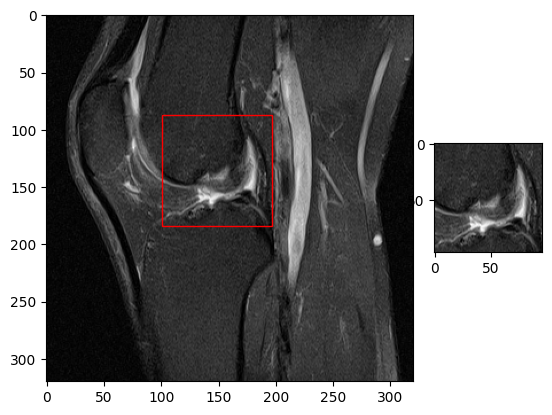

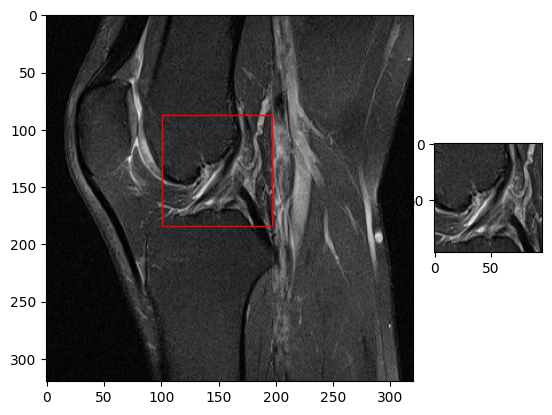

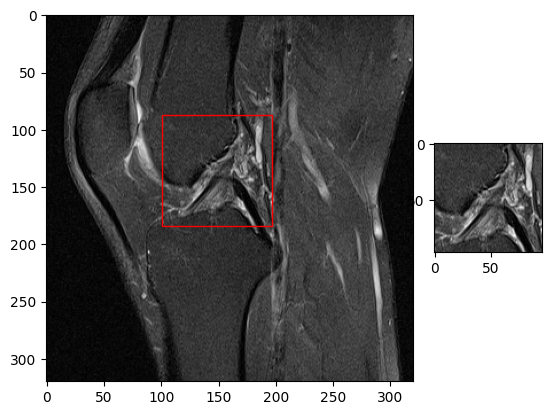

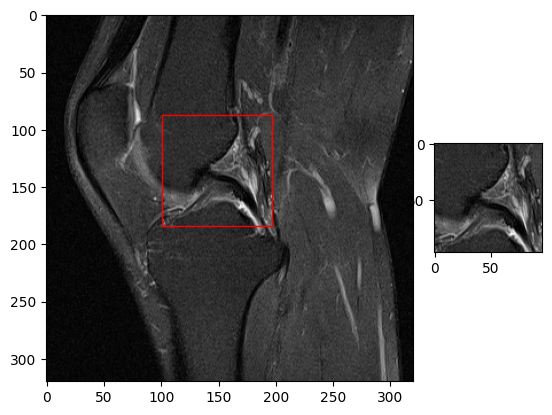

Diagnosis: 0


In [ ]:
"""
    Example showing how to access MRI scans
"""

import pickle
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patch

# directory where the volumetric data is located
volumetric_data_dir = '../input/vol01'

# path to metadata csv file
metadata_csv_path = '../input/metadata.csv'

# names=True loads the interprets the first row of csv file as column names
# 'i4' = 4 byte signed integer, 'U20' = unicode max 20 char string
metadata = np.genfromtxt(metadata_csv_path, delimiter=',', names=True,
    dtype='i4,i4,i4,i4,i4,i4,i4,i4,i4,i4,U20')

print('Column names:')
print(metadata.dtype.names)

# Select all rows where examID == 502889
exams = metadata[metadata['examId']==474967]

for exam in exams:
    vol_data_file = exam['volumeFilename']

    vol_data_path = os.path.join(volumetric_data_dir, vol_data_file)

    # Load data from file
    with open(vol_data_path, 'rb') as file_handler: # Must use 'rb' as the data is binary
        volumetric_data = pickle.load(file_handler)

    print('\nShape of volume "%s":' % vol_data_path, volumetric_data.shape)

    # Get all roi slices from volume
    z_start = exam['roiZ']
    depth = exam['roiDepth']
    label = exam['aclDiagnosis']


    for z in range(z_start, z_start + depth):

        slice = volumetric_data[z, :, :]

        # Get roi dimensions
        x, y, w, h = [exam[attr] for attr in ['roiX', 'roiY', 'roiWidth', 'roiHeight']]

        # Extract ROI
        roi = slice[y:y+h, x:x+w]

        # Plot slice and roi
        figure = plt.figure()
        plot = plt.subplot2grid((1, 4), (0, 0), 1, 3) # This makes the slice plot larger than roi plot
        plot.add_patch(patch.Rectangle((x, y), w, h, fill=None, color='red'))
        plot.imshow(slice, cmap='gray')
        plot = plt.subplot2grid((1, 4), (0, 3), 1, 1)
        plot.imshow(roi, cmap='gray')

        plt.show()
    print(f"Diagnosis: {label}")

In [ ]:
from pathlib import Path
import re
a=[]
df=pd.read_csv("../input/metadata.csv")
#df = df.sample(n=15)     # k rows
for MRI in df['volumeFilename']:
    for Dir in ("vol01","vol02","vol03","vol04","vol05","vol06","vol07","vol08"):

        my_file=Path("../input/"+Dir+"/"+MRI )

        if my_file.exists():
            a.append(my_file)


df['path']=3
string1=[]
new_df=pd.DataFrame()
for i in a:
    string1.append(str(i))
string1
for b in string1:
    for i, row in df.iterrows():

        string1=b.split('/')
        if re.match(row['volumeFilename'],string1[3]):
            row['path']=b
            df1=row.to_frame()
            df1_transposed = df1.T
            frames = [df,df1_transposed]
            df=pd.concat(frames)
            break
plt.ishold

AttributeError: module 'matplotlib.pyplot' has no attribute 'ishold'


Shape of volume "../input/vol01/329637-8.pck": (32, 320, 320)
Diagnosis: 0


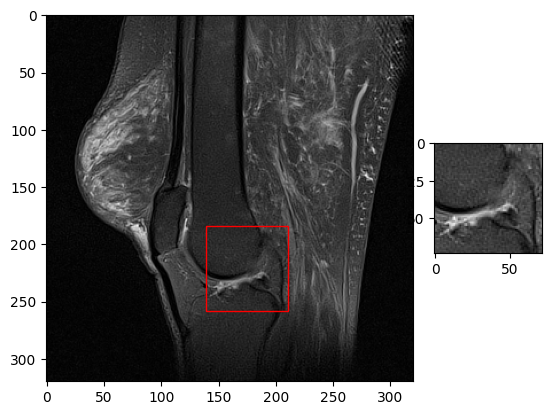

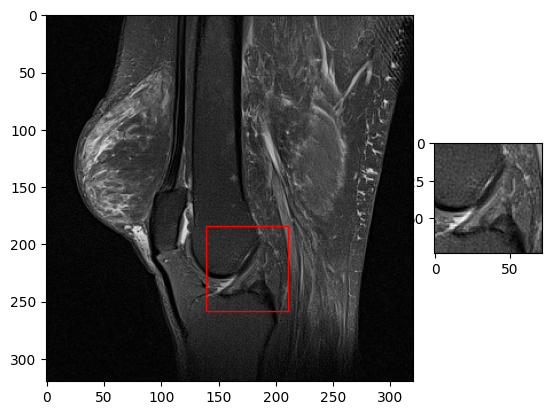

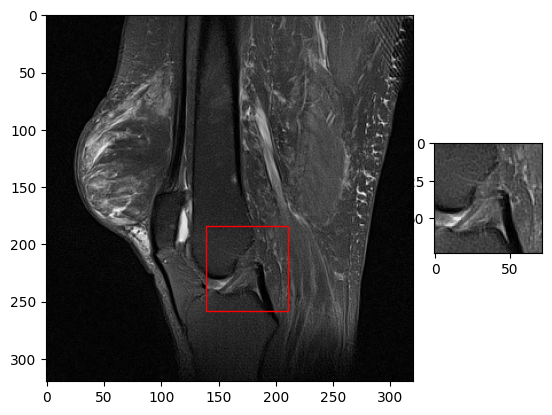

In [ ]:
exams = metadata[metadata['examId']==329637]

for exam in exams:
    vol_data_file = exam['volumeFilename']

    vol_data_path = os.path.join(volumetric_data_dir, vol_data_file)

    # Load data from file
    with open(vol_data_path, 'rb') as file_handler: # Must use 'rb' as the data is binary
        volumetric_data = pickle.load(file_handler)

    print('\nShape of volume "%s":' % vol_data_path, volumetric_data.shape)

    # Get all roi slices from volume
    z_start = exam['roiZ']
    depth = exam['roiDepth']
    label = exam['aclDiagnosis']
    print(f"Diagnosis: {label}")

    for z in range(z_start, z_start + depth):

        slice = volumetric_data[z, :, :]

        # Get roi dimensions
        x, y, w, h = [exam[attr] for attr in ['roiX', 'roiY', 'roiWidth', 'roiHeight']]

        # Extract ROI
        roi = slice[y:y+h, x:x+w]

        # Plot slice and roi
        figure = plt.figure()
        plot = plt.subplot2grid((1, 4), (0, 0), 1, 3) # This makes the slice plot larger than roi plot
        plot.add_patch(patch.Rectangle((x, y), w, h, fill=None, color='red'))
        plot.imshow(slice, cmap='gray')
        plot = plt.subplot2grid((1, 4), (0, 3), 1, 1)
        plot.imshow(roi, cmap='gray')

        plt.show()

In [ ]:
import pickle
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patch

# directory where the volumetric data is located
volumetric_data_dir = '../input/vol01'

# path to metadata csv file
metadata_csv_path = '../input/metadata.csv'

# names=True loads the interprets the first row of csv file as column names
# 'i4' = 4 byte signed integer, 'U20' = unicode max 20 char string
metadata = np.genfromtxt(metadata_csv_path, delimiter=',', names=True,
    dtype='i4,i4,i4,i4,i4,i4,i4,i4,i4,i4,U20')

print('Column names:')
print(metadata.dtype.names)

# Select all rows where examID == 502889
exams = metadata[metadata['examId'] == 404663]
vol_data_file = exam['volumeFilename']

vol_data_path = os.path.join(volumetric_data_dir, vol_data_file)
print(vol_data_path)
    # Load data from file
with open(vol_data_path, 'rb') as file_handler: # Must use 'rb' as the data is binary
    volumetric_data = pickle.load(file_handler)
roi=volumetric_data
plot.imshow(roi, cmap='gray')
plt.show()



Column names:
('examId', 'seriesNo', 'aclDiagnosis', 'kneeLR', 'roiX', 'roiY', 'roiZ', 'roiHeight', 'roiWidth', 'roiDepth', 'volumeFilename')
../input/vol01/463773-8.pck


TypeError: Invalid shape (32, 320, 320) for image data